In [15]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# =============================================================================
# 1. File discovery and loading
# =============================================================================

dir_without = '../datasets/CICEVSE2024/synthetic_nodes/03_1_individualized_nodes_withoutCoordiAttack/'
dir_with    = '../datasets/CICEVSE2024/synthetic_nodes/03_2_individualized_nodes_withCoordiAttack/'

def load_directory(directory, tag):
    """Load all CSVs from a directory, tag each row with node name and source tag."""
    frames = []
    csv_files = sorted(glob.glob(os.path.join(directory, '*.csv')))
    print(f"[{tag}] Found {len(csv_files)} files:")

    for path in csv_files:
        file_name = os.path.basename(path)
        print(f"  -> {file_name}")
        df = pd.read_csv(path)

        # --- DEFENSIVE COLUMN CREATION ---
        # 'Label' column: fallback to 'benign' if missing
        if 'Label' not in df.columns:
            df['Label'] = 'benign'
        else:
            df['Label'] = df['Label'].astype(str).str.lower().str.strip()

        # 'Attack' column: fallback to 'none' if missing (e.g. 03_1 without attack)
        if 'Attack' not in df.columns:
            df['Attack'] = 'none'
        else:
            df['Attack'] = df['Attack'].astype(str).str.lower().str.strip()
        # ----------------------------------

        df['node']    = os.path.splitext(file_name)[0]
        df['source']  = tag
        df['row_idx'] = np.arange(len(df))

        frames.append(df[['node', 'source', 'row_idx', 'Attack', 'Label']])

    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
df_without = load_directory(dir_without, 'without_coordi')
df_with    = load_directory(dir_with,    'with_coordi')

print(f"\nRows without coordinated attack: {len(df_without)}")
print(f"Rows with    coordinated attack: {len(df_with)}")

[without_coordi] Found 10 files:
  -> individualization_metadata.csv
  -> node_real_EVSE-B.csv
  -> node_synthetic_1_individualized.csv
  -> node_synthetic_2_individualized.csv
  -> node_synthetic_3_individualized.csv
  -> node_synthetic_4_individualized.csv
  -> node_synthetic_5_individualized.csv
  -> node_synthetic_6_individualized.csv
  -> node_synthetic_7_individualized.csv
  -> node_synthetic_8_individualized.csv
[with_coordi] Found 10 files:
  -> individualization_metadata.csv
  -> node_real_EVSE-B.csv
  -> node_synthetic_1_individualized.csv
  -> node_synthetic_2_individualized.csv
  -> node_synthetic_3_individualized.csv
  -> node_synthetic_4_individualized.csv
  -> node_synthetic_5_individualized.csv
  -> node_synthetic_6_individualized.csv
  -> node_synthetic_7_individualized.csv
  -> node_synthetic_8_individualized.csv

Rows without coordinated attack: 1036954
Rows with    coordinated attack: 1036954


In [16]:
# =============================================================================
# 2. Helper: derive attack_type column
# =============================================================================

def add_attack_type(df):
    df = df.copy()
    df['attack_type'] = np.where(
        df['Label'].eq('attack'),
        df['Attack'],
        'benign'
    )
    return df

df_without = add_attack_type(df_without)
df_with    = add_attack_type(df_with)

# Quick label distribution check
for tag, df in [('WITHOUT coordi', df_without), ('WITH coordi', df_with)]:
    print(f"\n--- {tag} ---")
    print(df['attack_type'].value_counts())


--- WITHOUT coordi ---
attack_type
vuln-scan        176427
backdoor         170067
syn-flood        142063
benign           141639
syn-stealth      137463
tcp-flood        136664
cryptojacking    132631
Name: count, dtype: int64

--- WITH coordi ---
attack_type
tcp-flood        216823
syn-flood        165770
vuln-scan        154814
backdoor         147964
benign           126297
syn-stealth      115789
cryptojacking    109497
Name: count, dtype: int64


In [17]:
# =============================================================================
# 3. Core plot function (mirrors your 02_coordinated_attack style)
# =============================================================================

def find_contiguous_ranges(rows, gap=2):
    """Merge row indices into contiguous windows given an allowed gap."""
    if not rows:
        return []
    ranges = []
    start = rows[0]
    prev  = rows[0]
    for r in rows[1:]:
        if r - prev > gap:
            ranges.append((start, prev))
            start = r
        prev = r
    ranges.append((start, prev))
    return ranges


def plot_eda(all_df, title, min_shared_nodes=4, figsize=(22, 10)):
    """
    Scatter plot of attack labels per node over row index.
    Red spans mark windows where >= min_shared_nodes share the same attack type.
    """
    node_order = sorted(all_df['node'].unique())
    node_to_y  = {node: i for i, node in enumerate(node_order)}
    all_df     = all_df.copy()
    all_df['y'] = all_df['node'].map(node_to_y)

    attack_types = sorted([x for x in all_df['attack_type'].unique() if x != 'benign'])
    palette      = plt.cm.tab20(np.linspace(0, 1, max(1, len(attack_types))))
    colors       = {'benign': '#9ca3af'}
    for i, attack in enumerate(attack_types):
        colors[attack] = palette[i]

    fig, ax = plt.subplots(figsize=figsize)

    # Scatter each attack type
    for attack_type, color in colors.items():
        subset = all_df[all_df['attack_type'] == attack_type]
        ax.scatter(
            subset['row_idx'],
            subset['y'],
            s=5,
            c=[color],
            alpha=0.65,
            linewidths=0,
        )

    # ------------------------------------------------------------------
    # Detect windows where >= min_shared_nodes share the same attack type
    # ------------------------------------------------------------------
    pivot = all_df.pivot_table(
        index='row_idx',
        columns='node',
        values='attack_type',
        aggfunc='first'
    )

    shared_rows = set()
    for attack in attack_types:
        count_per_row = (pivot == attack).sum(axis=1)
        matching      = count_per_row[count_per_row >= min_shared_nodes].index.tolist()
        shared_rows.update(matching)

    shared_rows = sorted(shared_rows)
    ranges      = find_contiguous_ranges(shared_rows, gap=2)

    n_nodes     = len(node_order)
    label_y_pos = n_nodes - 0.4   # just above the top node

    for (r_start, r_end) in ranges:
        ax.axvspan(r_start, r_end, color='red', alpha=0.15, linewidth=0)
        ax.axvline(r_start, color='red', linewidth=0.6, linestyle='--', alpha=0.7)
        ax.axvline(r_end,   color='red', linewidth=0.6, linestyle='--', alpha=0.7)

        span_data    = all_df[(all_df['row_idx'] >= r_start) & (all_df['row_idx'] <= r_end)]
        span_attacks = span_data[span_data['attack_type'] != 'benign']['attack_type']
        if not span_attacks.empty:
            dominant = span_attacks.value_counts().idxmax()
            mid_x    = (r_start + r_end) / 2
            ax.text(
                mid_x, label_y_pos,
                dominant,
                ha='center', va='bottom',
                fontsize=7,
                color='darkred',
                rotation=90,
                clip_on=True
            )

    # ------------------------------------------------------------------
    # Legend, axes, layout
    # ------------------------------------------------------------------
    ax.set_ylim(-0.5, n_nodes + 0.5)
    ax.set_yticks(range(n_nodes))
    ax.set_yticklabels(node_order, fontsize=8)
    ax.set_xlabel('Row index')
    ax.set_ylabel('Node / dataset')
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.25)

    legend_handles = [
        Line2D([0], [0], marker='o', color='w', label='benign',
               markerfacecolor=colors['benign'], markersize=8)
    ]
    for attack in attack_types:
        legend_handles.append(
            Line2D([0], [0], marker='o', color='w', label=attack,
                   markerfacecolor=colors[attack], markersize=8)
        )
    if ranges:
        legend_handles.append(
            Line2D([0], [0], color='red', alpha=0.5, linewidth=6,
                   label=f'Global event (>={min_shared_nodes} nodes)')
        )

    ax.legend(handles=legend_handles, loc='upper right', ncol=2, fontsize=8)
    plt.tight_layout()
    plt.savefig(f'output/{title[:60].replace(" ", "_").replace("/", "-")}.png', dpi=150)
    plt.show()
    print(f"Detected {len(ranges)} shared-attack windows.")

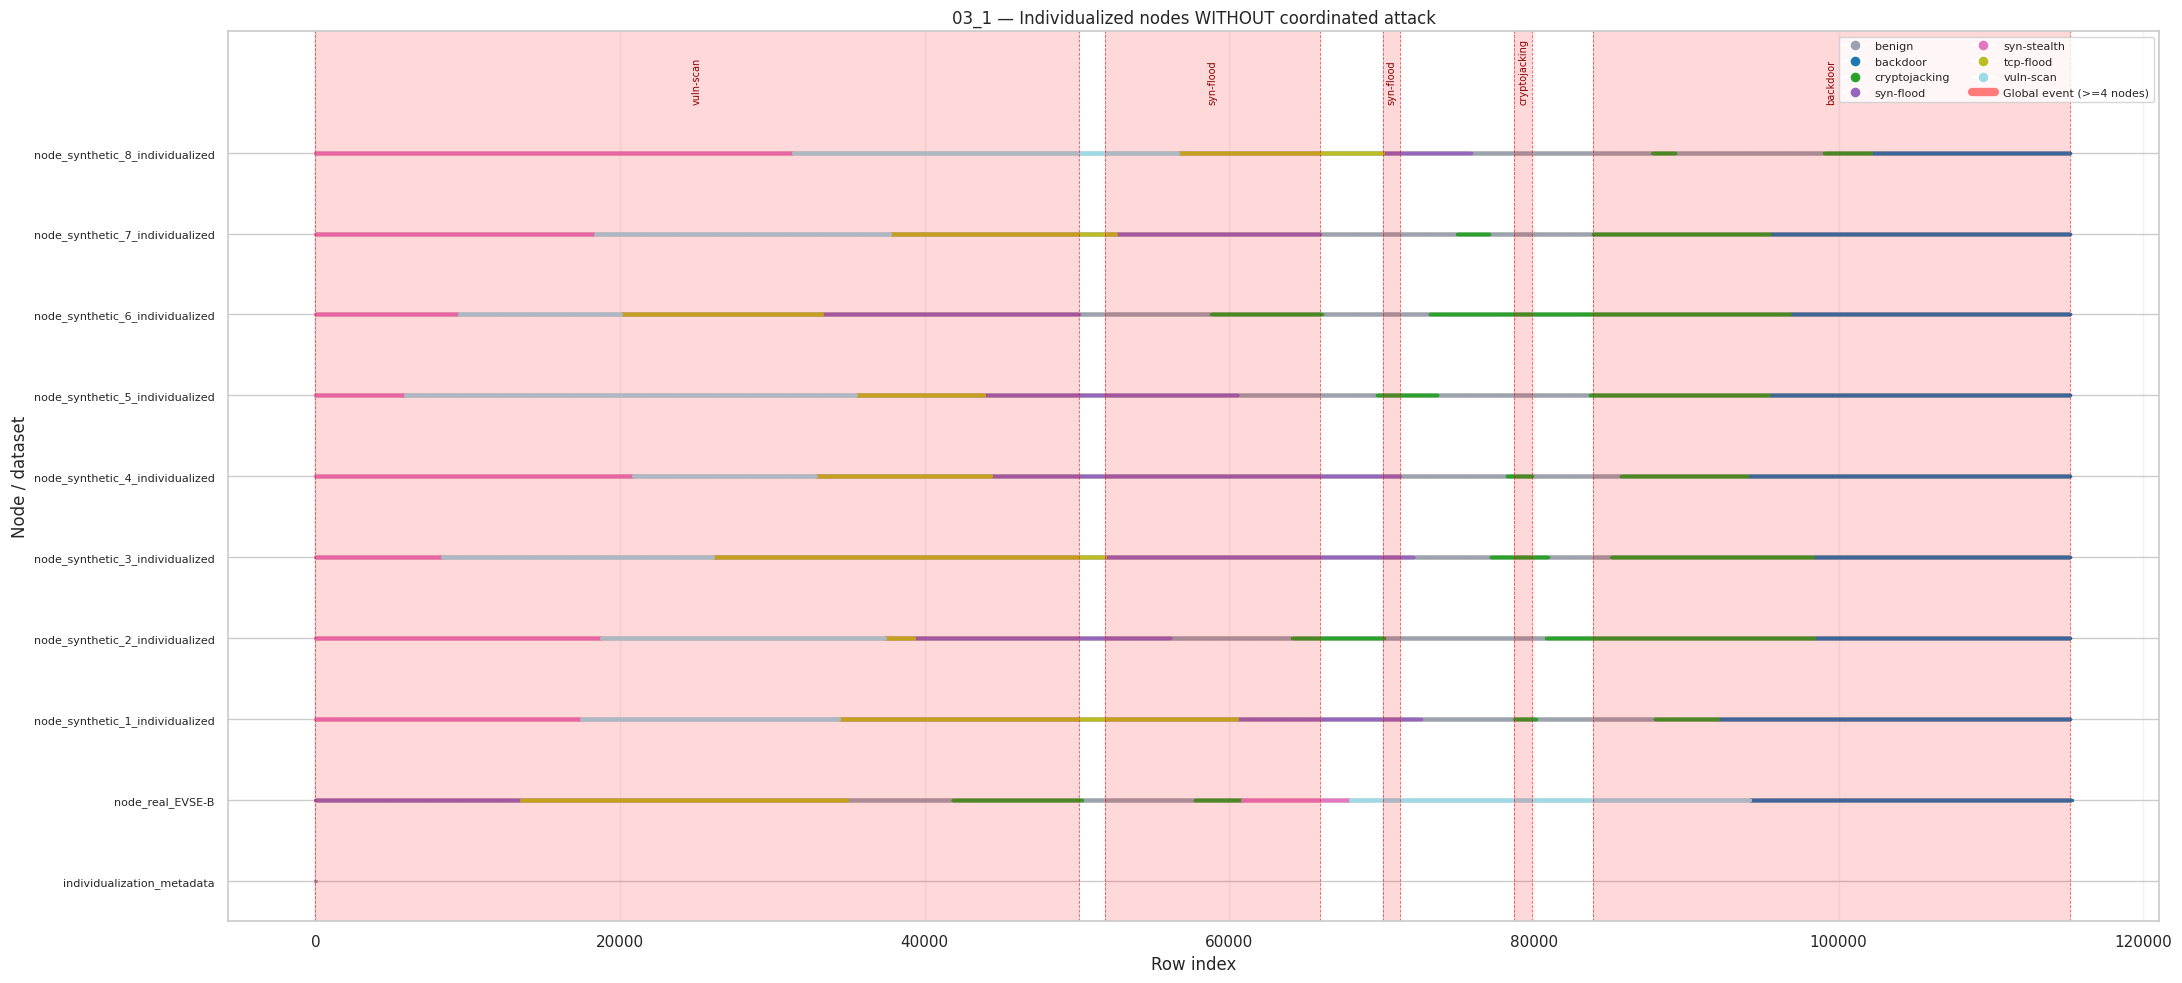

Detected 5 shared-attack windows.


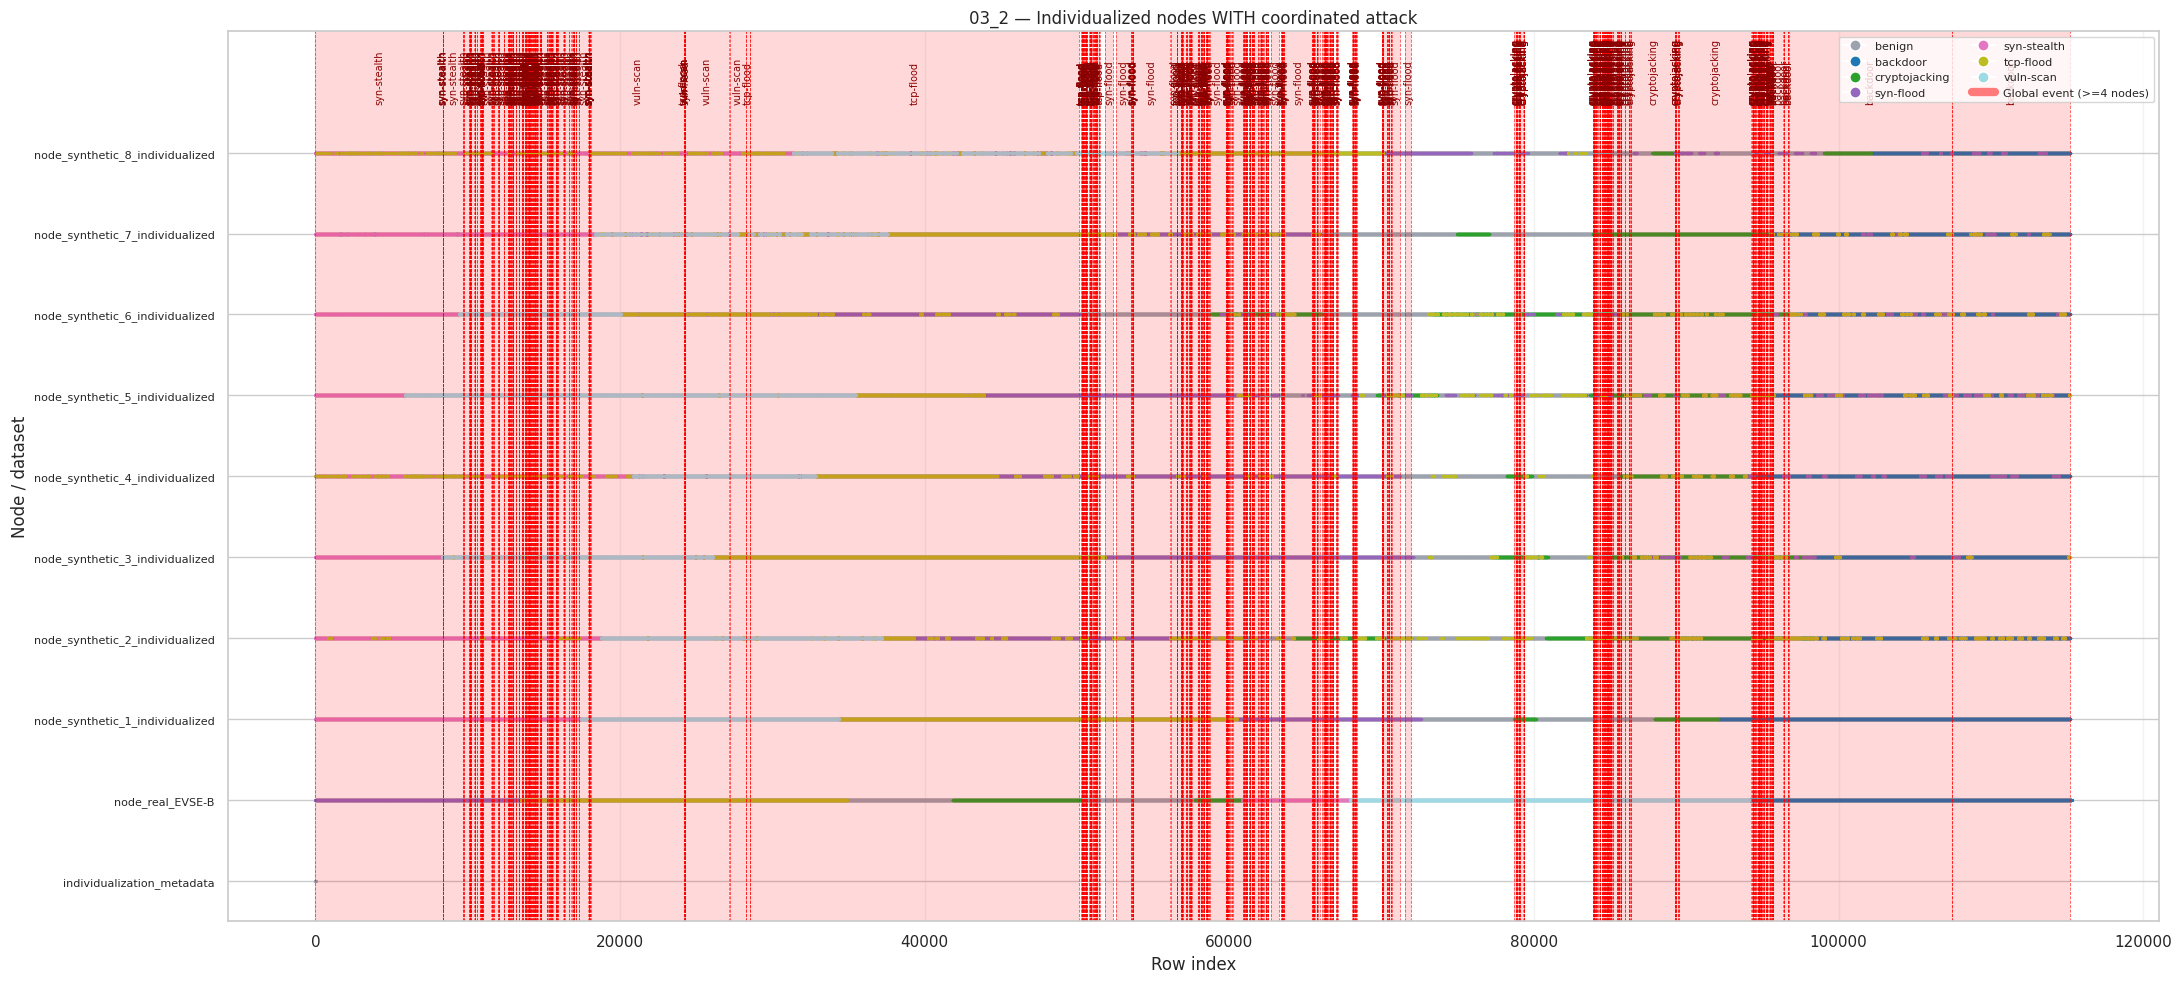

Detected 487 shared-attack windows.


In [19]:
# =============================================================================
# 4. Plot 1 — Without Coordinated Attack
# =============================================================================

os.makedirs('output', exist_ok=True)

plot_eda(
    df_without,
    title='03_1 — Individualized nodes WITHOUT coordinated attack',
    min_shared_nodes=4
)

# =============================================================================
# 5. Plot 2 — With Coordinated Attack
# =============================================================================

plot_eda(
    df_with,
    title='03_2 — Individualized nodes WITH coordinated attack',
    min_shared_nodes=4
)

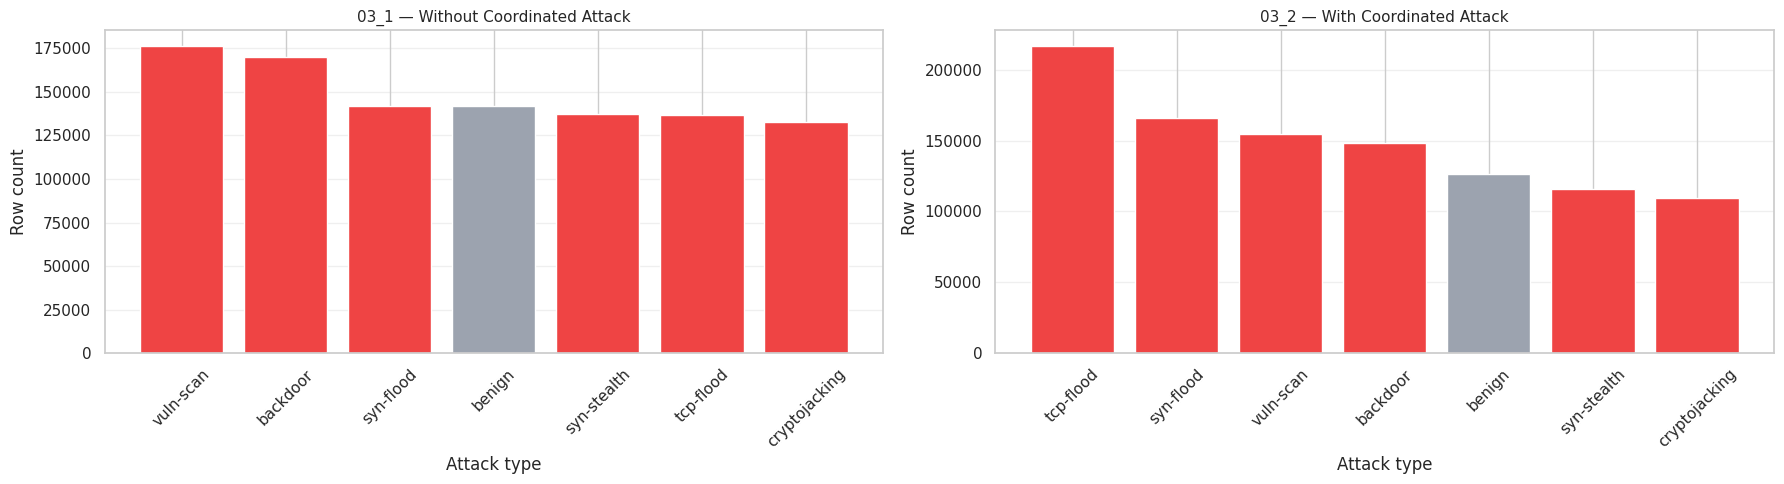

In [20]:
# =============================================================================
# 6. Side-by-side label distribution bar chart
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, (df, label) in zip(axes, [
    (df_without, '03_1 — Without Coordinated Attack'),
    (df_with,    '03_2 — With Coordinated Attack')
]):
    counts = df['attack_type'].value_counts().sort_values(ascending=False)
    colors_bar = ['#9ca3af' if k == 'benign' else '#ef4444' for k in counts.index]
    ax.bar(counts.index, counts.values, color=colors_bar, edgecolor='white')
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Attack type')
    ax.set_ylabel('Row count')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('output/03_label_distribution_comparison.png', dpi=150)
plt.show()